<a href="https://colab.research.google.com/github/Tetsu-Tetsuya/Desafio-MNIST-classificador/blob/main/ML__Autoenconder_vers%C3%A3o_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import scipy.io # Adicionado para ler arquivos .mat

# autoencoder_1D

In [2]:
def build_autoencoder():
    inputs = layers.Input(shape=(2048, 1))

    # Encoder: Camadas de convolução seguidas de redução (Downsampling)
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs) # (2048, 32)
    x = layers.MaxPooling1D(2)(x) # (1024, 32)
    x = layers.Conv1D(16, 7, activation='relu', padding='same')(x) # (1024, 16)
    x = layers.MaxPooling1D(2)(x) # (512, 16)

    # Latent Space: Representação comprimida do sinal "perfeito"
    latent = layers.Conv1D(8, 7, activation='relu', padding='same')(x) # (512, 8)

    # Decoder: Reconstrução do sinal original
    x = layers.UpSampling1D(2)(latent) # (1024, 8)
    x = layers.Conv1D(16, 7, activation='relu', padding='same')(x) # (1024, 16)
    x = layers.UpSampling1D(2)(x) # (2048, 16)
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(x) # (2048, 32)

    # Saída final ajustada para o tamanho original
    outputs = layers.Conv1D(1, 7, activation='linear', padding='same')(x) # (2048, 1)

    return models.Model(inputs, outputs)

# calcular_limiar

In [13]:
def calcular_limiar_artigo(model, x_train_normal, percentile=99):
    """
    Calcula o limiar de anomalia usando o percentil dos erros de reconstrução
    nos dados de treino 'normais'.

    Args:
        model (tf.keras.Model): O modelo Autoencoder treinado.
        x_train_normal (np.array): Dados de treino 'normais' usados para calcular o limiar.
        percentile (int): O percentil a ser usado para definir o limiar (ex: 99 para 99º percentil).

    Returns:
        float: O limiar calculado.
    """
    # Predição nos dados sem defeito
    reconstructions = model.predict(x_train_normal, verbose=0)
    # Cálculo do erro médio por amostra
    mse = np.mean(np.power(x_train_normal - reconstructions, 2), axis=(1, 2))

    # Define o limiar como o percentil especificado dos erros de reconstrução
    threshold = np.percentile(mse, percentile)
    return threshold

# processar_sinal_bruto

In [4]:
def processar_sinal_bruto(sinal_bruto_1d):
    """
    Função para garantir que um sinal 1D tenha 2048 pontos.
    Espera um array numpy 1D como entrada.
    """
    try:
        # 1. Garantir que o sinal tem 2048 pontos ou truncar/preencher se necessário.
        if len(sinal_bruto_1d) != 2048:
            print(f"Aviso: O sinal de entrada não tem 2048 pontos. Tem {len(sinal_bruto_1d)}. "
                  "O processamento pode não ser o esperado. Ajustando para 2048.")
            # Implementar padding/truncamento para garantir 2048 pontos
            sinal_bruto_1d = np.pad(sinal_bruto_1d, (0, max(0, 2048 - len(sinal_bruto_1d))))[:2048]

        return sinal_bruto_1d

    except Exception as e:
        print(f"Erro ao processar o sinal: {e}")
        return None

# carregar_dados

In [5]:
import os
import numpy as np
import pandas as pd
import random
import scipy.io # Para carregar arquivos .mat

def carregar_dados(root_data_dir, semdefeito_file_name="yf-semdefeito.mat", other_defect_file_names=None, mat_key='yf'):
    """
    Carrega, processa e divide os dados de treino e teste.

    Args:
        root_data_dir (str): O caminho para o diretório raiz
        semdefeito_file_name (str): O nome do arquivo que contém os dados 'sem defeito'. Default é "yf-semdefeito.mat".
        other_defect_file_names (list, optional): Uma lista de nomes dos arquivos .mat que contêm
                                                    os dados com diferentes tipos de defeito.
                                                    Se None, usa "yf-faltadefusao.mat", "yf-inclusaoescoria.mat", "yf-porosidade.mat", "yf-trinca.mat"
        mat_key (str): A chave dentro do arquivo .mat para acessar o array de dados do sinal.

    Returns:
        tuple: (X_train_processed, test_samples_processed)
            - X_train_processed (np.array): Dados de treino processados, formatados para o autoencoder (shape: (num_samples, 2048, 1)).
            - test_samples_processed (list): Uma lista de tuplas, onde cada tupla contém:
                                            (sinal_normalizado, 'label_da_categoria').
                                            'label_da_categoria' pode ser 'NORMAL' ou o nome do arquivo de defeito (sem .mat).
                                            Estes são os dados para avaliação.
    """
    if other_defect_file_names is None:
        other_defect_file_names = ["yf-faltadefusao.mat", "yf-inclusaoescoria.mat", "yf-porosidade.mat", "yf-trinca.mat"]

    # Caminho completo para o arquivo de dados 'sem defeito'
    semdefeito_path = os.path.join(root_data_dir, semdefeito_file_name)

    if not os.path.exists(semdefeito_path):
        print(f"Erro: Arquivo de dados 'sem defeito' não encontrado: {semdefeito_path}")
        return None, None

    try:
        # Carrega todos os dados 'sem defeito' de uma vez
        mat_data_semdefeito = scipy.io.loadmat(semdefeito_path)
        all_semdefeito_signals = mat_data_semdefeito[mat_key]
        # all_semdefeito_signals agora é um array (200, 2048)

        if all_semdefeito_signals.shape[0] < 200:
            print(f"Erro: Poucas amostras em '{semdefeito_file_name}'. Encontradas {all_semdefeito_signals.shape[0]}, esperado 200 para treino/teste.")
            return None, None

        # Embaralha os índices e divide em 180 para treino e 20 para teste
        indices = np.arange(all_semdefeito_signals.shape[0])
        random.shuffle(indices)
        train_indices = indices[:180]
        test_indices_normal = indices[180:200]

        # 2. Carrega e processa os dados de treino (yf-semdefeito)
        X_train_list = []
        print(f"Carregando e processando {len(train_indices)} amostras de treino (yf-semdefeito)...")
        for idx in train_indices:
            sinal_bruto = all_semdefeito_signals[idx, :]
            sinal_norm = processar_sinal_bruto(sinal_bruto)
            if sinal_norm is not None and sinal_norm.shape[0] == 2048: # Novo tamanho esperado
                X_train_list.append(sinal_norm)
            else:
                print(f"Aviso: Amostra {idx} de {semdefeito_file_name} (treino) não processada corretamente ou tem shape incorreto. Ignorando.")

        if not X_train_list:
            print("Erro: Nenhum dado de treino válido foi carregado.")
            return None, None

        X_train_processed = np.array(X_train_list).reshape(-1, 2048, 1) # Novo shape

        # 3. Prepara o conjunto de teste
        test_samples_processed = []

        # Adiciona as 20 amostras 'sem defeito' para o teste
        print(f"Preparando {len(test_indices_normal)} amostras 'sem defeito' para teste...")
        for idx in test_indices_normal:
            sinal_bruto = all_semdefeito_signals[idx, :]
            sinal_norm = processar_sinal_bruto(sinal_bruto)
            if sinal_norm is not None and sinal_norm.shape[0] == 2048: # Novo tamanho esperado
                test_samples_processed.append((sinal_norm, "NORMAL"))
            else:
                print(f"Aviso: Amostra {idx} de {semdefeito_file_name} (teste - normal) não processada corretamente. Ignorando.")

        # Adiciona 10 amostras de cada uma das outras categorias de defeito para teste
        for defect_file_name in other_defect_file_names:
            defect_path = os.path.join(root_data_dir, defect_file_name)
            if os.path.exists(defect_path):
                mat_data_defect = scipy.io.loadmat(defect_path)
                all_defect_signals = mat_data_defect[mat_key]

                if all_defect_signals.shape[0] < 10:
                    print(f"Aviso: Poucas amostras em '{defect_file_name}'. Encontradas {all_defect_signals.shape[0]}, esperado 10. Usando todas disponíveis.")
                    selected_defect_indices = np.arange(all_defect_signals.shape[0])
                else:
                    selected_defect_indices = random.sample(range(all_defect_signals.shape[0]), 10)

                defect_label = defect_file_name.replace('.mat', '') # Usar o nome do arquivo como label
                print(f"Preparando {len(selected_defect_indices)} amostras de '{defect_label}' para teste...")
                for idx in selected_defect_indices:
                    sinal_bruto = all_defect_signals[idx, :]
                    sinal_norm = processar_sinal_bruto(sinal_bruto)
                    if sinal_norm is not None and sinal_norm.shape[0] == 2048: # Novo tamanho esperado
                        test_samples_processed.append((sinal_norm, defect_label))
                    else:
                        print(f"Aviso: Amostra {idx} de {defect_file_name} (teste - {defect_label}) não processada corretamente. Ignorando.")
            else:
                print(f"Aviso: Arquivo de defeito '{defect_path}' não encontrado. Ignorando esta categoria.")

        print(f"\nResumo da carga de dados:")
        print(f"  Total de amostras de treino (yf-semdefeito): {len(X_train_list)}")
        print(f"  Total de amostras de teste: {len(test_samples_processed)}")
        print(f"    - yf-semdefeito (NORMAL): {len([s for s, l in test_samples_processed if l == 'NORMAL'])}")
        for defect_file_name in other_defect_file_names:
            defect_label = defect_file_name.replace('.mat', '')
            print(f"    - {defect_label}: {len([s for s, l in test_samples_processed if l == defect_label])}")

        return X_train_processed, test_samples_processed

    except Exception as e:
        print(f"Erro geral ao carregar dados: {e}")
        return None, None

# Gerar CSV

In [7]:
def gerar_dataset_original(diretorio_origem, pasta_destino):
    X_data = []

    # Criar pasta de destino se não existir
    if not os.path.exists(pasta_destino):
        os.makedirs(pasta_destino)

    print(f"Lendo arquivos originais em: {diretorio_origem}")

    # Loop para os 150 arquivos originais (ajustado de 200)
    for i in range(1, 151):
        nome_arquivo = f"1_ ({i}).txt"
        caminho_completo = os.path.join(diretorio_origem, nome_arquivo)

        if os.path.exists(caminho_completo):
            try:
                # skiprows=22 para garantir os 2500 pontos
                df = pd.read_csv(caminho_completo, sep=None, engine='python', skiprows=22, header=None)
                sinal = df.iloc[:, 1].values.astype(np.float32)

                # Ajuste para 2500 pontos
                if len(sinal) == 2499:
                    sinal = np.append(sinal, sinal[-1])
                elif len(sinal) > 2500:
                    sinal = sinal[:2500]

                if len(sinal) == 2500:
                    # Normalização Z-score (StandardScaler)
                    # O StandardScaler espera entrada 2D (n_samples, n_features)
                    # Nosso sinal é 1D, então o reshape para (2500, 1) é necessário
                    scaler = StandardScaler()
                    sinal_norm = scaler.fit_transform(sinal.reshape(-1, 1)).flatten()

                    # ADICIONA APENAS O SINAL ORIGINAL
                    X_data.append(sinal_norm)
                else:
                    print(f"Aviso: {nome_arquivo} ignorado ({len(sinal)} pontos).")

            except Exception as e:
                print(f"Erro ao ler {nome_arquivo}: {e}")
        else:
            print(f"Arquivo não encontrado: {nome_arquivo}")

    if len(X_data) > 0:
        X_train = np.array(X_data).reshape(-1, 2500, 1)
        caminho_save = os.path.join(pasta_destino, "dataset_treino_puro.npy")
        np.save(caminho_save, X_train)
        print("-" * 30)
        print(f"CONCLUÍDO! Dataset gerado com {len(X_train)} amostras.")
        print(f"Formato final (Shape): {X_train.shape}")
        print(f"Arquivo salvo em: {caminho_save}")
        return X_train
    else:
        print("ERRO: Nenhuma amostra carregada.")
        return None

# Main

In [16]:
# --- FUNÇÃO PRINCIPAL (MAIN) ---

def main():
    # Remover 'history_for_plotting' do escopo global se não for estritamente necessário fora da função

    # 1. Configurações de Caminhos
    ROOT_DATA_DIR = "/content/drive/MyDrive/Dados" # Caminho raiz dos seus dados
    MODEL_DIR = "/content/drive/MyDrive/modelo" # Diretório para salvar modelo e limiar
    CSV_SAIDA = os.path.join(MODEL_DIR, "log_inspecao_solda.csv") # Saída CSV para resultados da inspeção

    # Garante que o diretório do modelo exista
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    MODELO_PATH = os.path.join(MODEL_DIR, "modelo_puro.h5")
    THRESHOLD_PATH = os.path.join(MODEL_DIR, "threshold.npy")

    modelo = None
    limiar = None
    for_plotting = None # Inicializa for_plotting localmente

    # 1. Carregar ou Treinar o Modelo e o Limiar
    if os.path.exists(MODELO_PATH) and os.path.exists(THRESHOLD_PATH):
        print("Carregando modelo e limiar existentes...")
        # Explicitamente informa ao Keras que 'mse' é uma função de perda
        modelo = tf.keras.models.load_model(MODELO_PATH, custom_objects={'mse': tf.keras.losses.MeanSquaredError})
        limiar = np.load(THRESHOLD_PATH)
        print(f"Limiar carregado: {limiar}")
    else:
        print("Modelo ou limiar não encontrados. Iniciando treinamento...")

        # Carrega e processa os dados de treino e teste usando a nova função carregar_dados
        X_train, test_samples_processed = carregar_dados(ROOT_DATA_DIR)

        if X_train is None or test_samples_processed is None:
            print("Erro: Falha ao carregar dados. Treinamento abortado.")
            return

        print(f"Dataset de treino gerado com {X_train.shape[0]} amostras e shape: {X_train.shape}")

        # Constrói o autoencoder
        modelo = build_autoencoder()
        # COMPILA O MODELO
        modelo.compile(optimizer='adam', loss='mse')

        # Treina o modelo (ALTERAR O epochs para alterar a Epoch do treinamento)
        print("Iniciando treinamento do Autoencoder...")
        for_plotting = modelo.fit(X_train, X_train, epochs=50, batch_size=16,
                             validation_split=0.1, verbose=1)
        print("Treinamento concluído.")

        # Salva o modelo treinado
        modelo.save(MODELO_PATH)
        print(f"Modelo salvo em: {MODELO_PATH}")

        # Calcula e salva o limiar de anomalia usando o 99º percentil
        limiar = calcular_limiar_artigo(modelo, X_train, percentile=99) # Usando o 99º percentil
        np.save(THRESHOLD_PATH, limiar)
        print(f"Limiar calculado e salvo: {limiar}")

    # 2. Se o modelo foi carregado, ainda precisamos carregar os dados de teste
    if modelo is not None and limiar is not None and for_plotting is None: # Modelo carregado, não treinado agora
        _, test_samples_processed = carregar_dados(ROOT_DATA_DIR) # Carrega apenas os dados de teste
        if test_samples_processed is None:
            print("Erro: Falha ao carregar dados de teste para inspeção. Abortando.")
            return

    # 3. Executar Inspeção (usando o modelo treinado/carregado e limiar)
    print(f"\nIniciando inspeção com {len(test_samples_processed)} amostras de teste...")
    resultados_log = []

    for sinal_norm, label_original in test_samples_processed:
        entrada = sinal_norm.reshape(1, 2048, 1)
        reconstrucao = modelo.predict(entrada, verbose=0)
        score = np.mean(np.square(sinal_norm - reconstrucao))

        status = "NORMAL" if score <= limiar else "DEFEITO"

        resultados_log.append({
            "Id da RUN": label_original, # label_original para identificação
            "Score": round(float(score), 6),
            "Deliveres": 1,
            "steps": 2048,
            "seed": 42,
            "status": status
        })

    df_resultado = pd.DataFrame(resultados_log)

    # 4. Salvar e Exibir Resultados
    if not df_resultado.empty:
        df_resultado.to_csv(CSV_SAIDA, index=False)
        print(f"\nRelatório de inspeção gerado com sucesso em: {CSV_SAIDA}")
        print(df_resultado.head())

    else:
        print("Nenhum dado processado na inspeção.")

    print (limiar)

if __name__ == "__main__":
    main()

Modelo ou limiar não encontrados. Iniciando treinamento...
Carregando e processando 180 amostras de treino (yf-semdefeito)...
Preparando 20 amostras 'sem defeito' para teste...
Preparando 10 amostras de 'yf-faltadefusao' para teste...
Preparando 10 amostras de 'yf-inclusaoescoria' para teste...
Preparando 10 amostras de 'yf-porosidade' para teste...
Preparando 10 amostras de 'yf-trinca' para teste...

Resumo da carga de dados:
  Total de amostras de treino (yf-semdefeito): 180
  Total de amostras de teste: 60
    - yf-semdefeito (NORMAL): 20
    - yf-faltadefusao: 10
    - yf-inclusaoescoria: 10
    - yf-porosidade: 10
    - yf-trinca: 10
Dataset de treino gerado com 180 amostras e shape: (180, 2048, 1)
Iniciando treinamento do Autoencoder...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 7.9123e-04 - val_loss: 3.9663e-04
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 3.6450e-04 - val_loss: 3.2787e-04
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 3

Treinamento concluído.
Modelo salvo em: /content/drive/MyDrive/modelo/modelo_puro.h5
Limiar calculado e salvo: 0.0001418375945509705

Iniciando inspeção com 60 amostras de teste...

Relatório de inspeção gerado com sucesso em: /content/drive/MyDrive/modelo/log_inspecao_solda.csv
  Id da RUN     Score  Deliveres  steps  seed   status
0    NORMAL  0.001781          1   2048    42  DEFEITO
1    NORMAL  0.003770          1   2048    42  DEFEITO
2    NORMAL  0.003095          1   2048    42  DEFEITO
3    NORMAL  0.001881          1   2048    42  DEFEITO
4    NORMAL  0.001997          1   2048    42  DEFEITO
0.0001418375945509705


# Analise de dados

Carregando e processando 180 amostras de treino (yf-semdefeito)...
Preparando 20 amostras 'sem defeito' para teste...
Preparando 10 amostras de 'yf-faltadefusao' para teste...
Preparando 10 amostras de 'yf-inclusaoescoria' para teste...
Preparando 10 amostras de 'yf-porosidade' para teste...
Preparando 10 amostras de 'yf-trinca' para teste...

Resumo da carga de dados:
  Total de amostras de treino (yf-semdefeito): 180
  Total de amostras de teste: 60
    - yf-semdefeito (NORMAL): 20
    - yf-faltadefusao: 10
    - yf-inclusaoescoria: 10
    - yf-porosidade: 10
    - yf-trinca: 10
Plotando os primeiros 2 sinais normais.


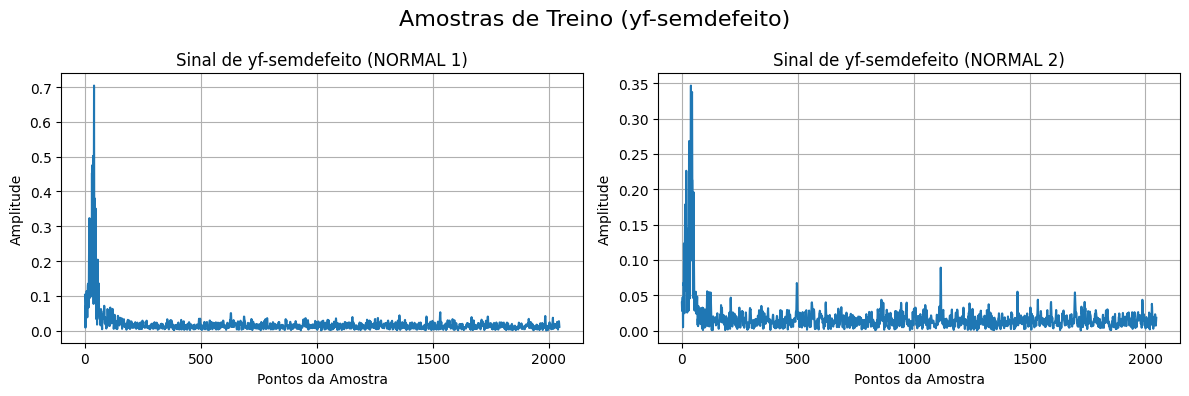

In [9]:
import matplotlib.pyplot as plt

# Define o diretório raiz dos dados
ROOT_DATA_DIR = "/content/drive/MyDrive/Dados"

# Carrega os dados de treino e teste
X_train_processed, test_samples_processed = carregar_dados(ROOT_DATA_DIR)

if X_train_processed is None or test_samples_processed is None:
    print("Não foi possível carregar os dados para plotagem.")
else:
    sample_plots = []
    # Coleta os 4 primeiros sinais 'normal' (yf-semdefeito) do conjunto de treino
    if X_train_processed.shape[0] > 0:
        num_normal_to_plot = min(2, X_train_processed.shape[0])
        print(f"Plotando os primeiros {num_normal_to_plot} sinais normais.")
        for i in range(num_normal_to_plot):
            sample_plots.append((f"yf-semdefeito (NORMAL {i+1})", X_train_processed[i].flatten()))
    else:
        print("Aviso: Nenhum dado de treino 'normal' disponível para plotar.")

    # Plotar os gráficos
    if sample_plots:
        num_plots = len(sample_plots) # This will be 4

        # For a 2x2 grid, we explicitly set rows and cols
        nrows = 1
        ncols = 2

        # Ensure num_plots does not exceed the grid capacity, or handle it
        if num_plots > (nrows * ncols):
            print(f"Warning: Only plotting the first {nrows * ncols} signals in a {nrows}x{ncols} grid. Total signals available: {num_plots}")
            sample_plots = sample_plots[:nrows * ncols]
            num_plots = nrows * ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharex=True)

        # Flatten the axes array for easy iteration
        axes = axes.flatten()

        for i, (label, signal) in enumerate(sample_plots):
            axes[i].plot(signal)
            axes[i].set_title(f'Sinal de {label}')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True)

        # Hide any unused subplots if num_plots is less than (nrows * ncols)
        for j in range(num_plots, len(axes)):
            fig.delaxes(axes[j])

        # Set xlabel on the bottom row plots
        for ax_idx in range(len(axes) - ncols, len(axes)):
            if ax_idx >= 0 and ax_idx < num_plots: # Ensure index is valid and subplot is used
                axes[ax_idx].set_xlabel('Pontos da Amostra')

        plt.suptitle('Amostras de Treino (yf-semdefeito)', fontsize=16)
        plt.tight_layout()
        plt.show()

    else:
        print("Nenhum sinal coletado para plotagem.")

Carregando e processando 180 amostras de treino (yf-semdefeito)...
Preparando 20 amostras 'sem defeito' para teste...
Preparando 10 amostras de 'yf-faltadefusao' para teste...
Preparando 10 amostras de 'yf-inclusaoescoria' para teste...
Preparando 10 amostras de 'yf-porosidade' para teste...
Preparando 10 amostras de 'yf-trinca' para teste...

Resumo da carga de dados:
  Total de amostras de treino (yf-semdefeito): 180
  Total de amostras de teste: 60
    - yf-semdefeito (NORMAL): 20
    - yf-faltadefusao: 10
    - yf-inclusaoescoria: 10
    - yf-porosidade: 10
    - yf-trinca: 10
Plotando os primeiros 2 sinais para cada tipo de defeito...


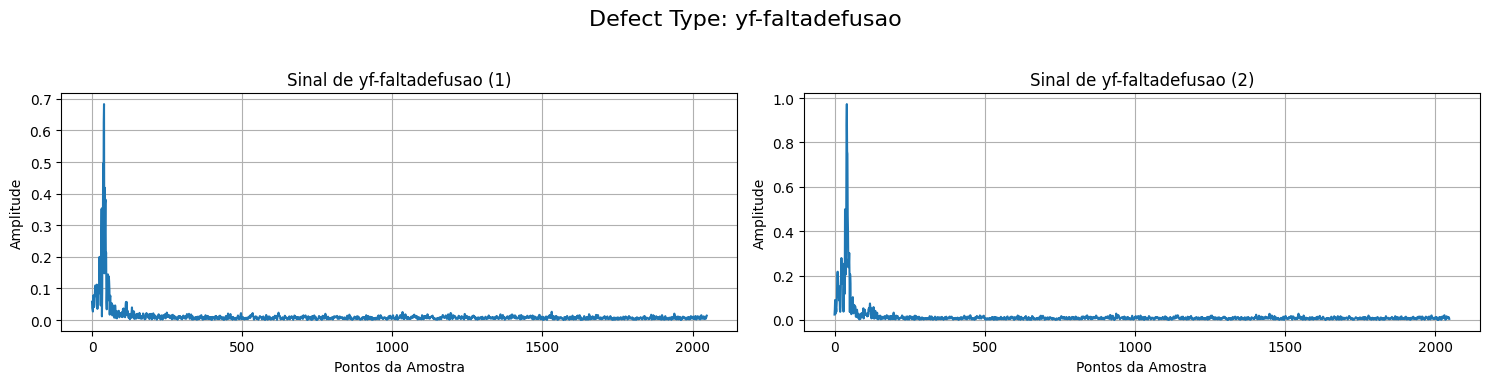

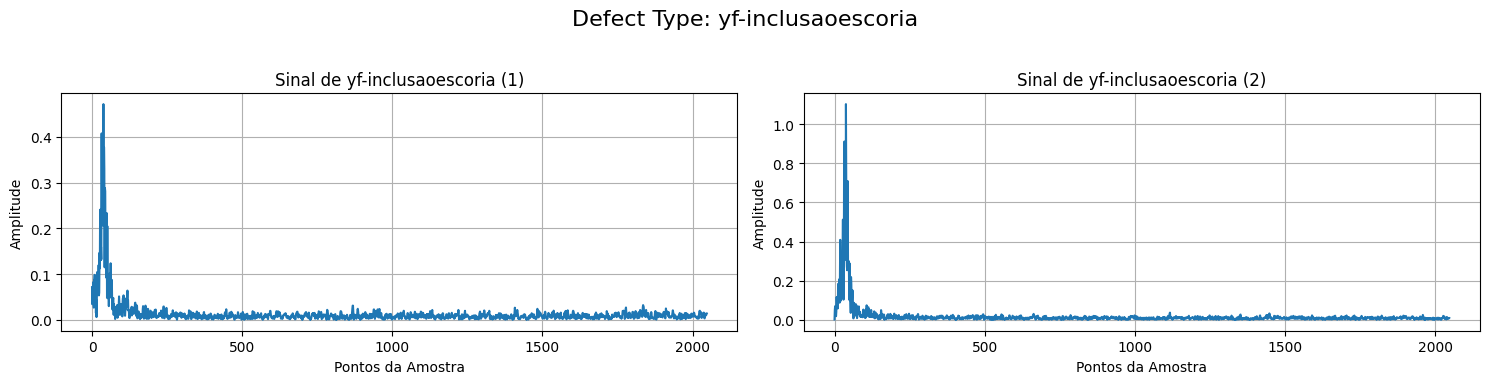

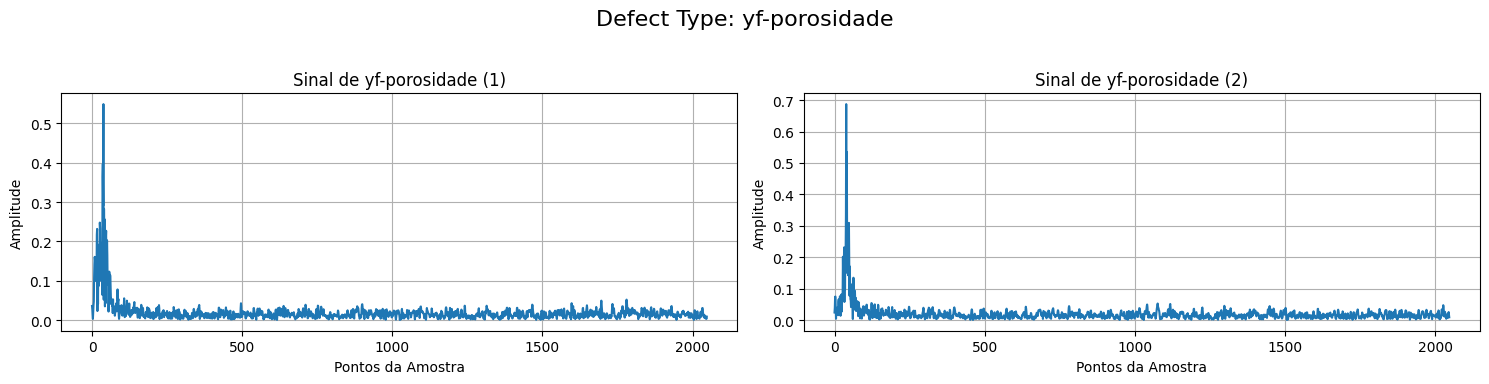

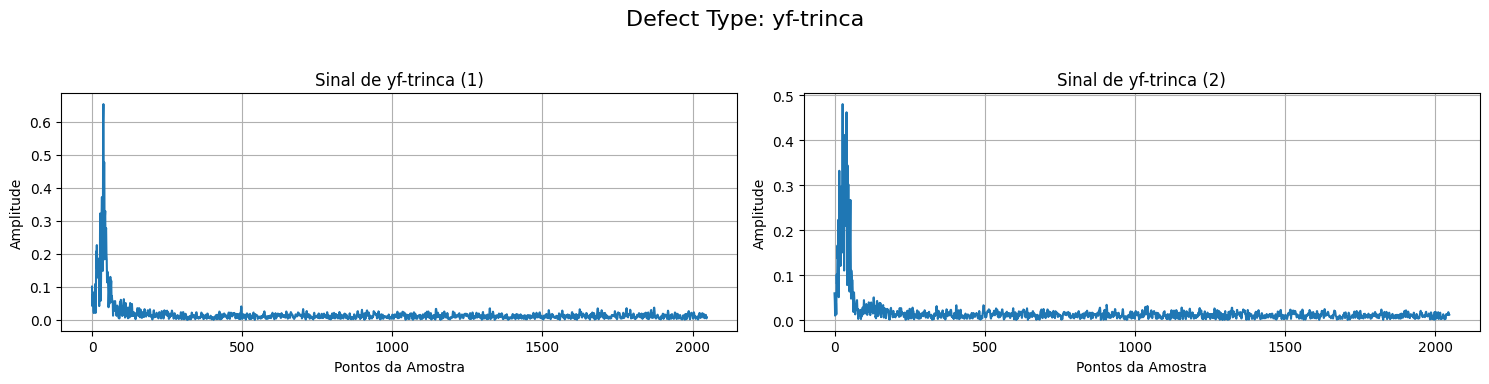

In [10]:
import matplotlib.pyplot as plt

# Define o diretório raiz dos dados
ROOT_DATA_DIR = "/content/drive/MyDrive/Dados"

# Carrega os dados de treino e teste
X_train_processed, test_samples_processed = carregar_dados(ROOT_DATA_DIR)

if X_train_processed is None or test_samples_processed is None:
    print("Não foi possível carregar os dados para plotagem.")
else:
    sample_plots = []

    # Dicionário para controlar quantos exemplos de cada tipo de defeito já foram coletados
    defeito_count = {}
    max_por_defeito = 2

    # Coleta 2 amostras de cada tipo de defeito do conjunto de teste
    print(f"Plotando os primeiros {max_por_defeito} sinais para cada tipo de defeito...")
    for signal, label in test_samples_processed:
        if label != "NORMAL": # Ignorar sinais normais, pois o pedido é para 'tipo de erro'
            if label not in defeito_count:
                defeito_count[label] = 0

            if defeito_count[label] < max_por_defeito:
                sample_plots.append((label + f" ({defeito_count[label] + 1})", signal.flatten()))
                defeito_count[label] += 1

    # Plotar os gráficos
    if sample_plots:
        # Group samples by defect type for individual 1x2 grids
        plots_by_defect_type = {}
        for label_full, signal_data in sample_plots:
            # Extract base defect label (e.g., 'yf-faltadefusao' from 'yf-faltadefusao (1)')
            base_label = label_full.split(' ')[0]
            if base_label not in plots_by_defect_type:
                plots_by_defect_type[base_label] = []
            plots_by_defect_type[base_label].append((label_full, signal_data))

        for defect_type, plots_for_type in plots_by_defect_type.items():
            nrows = 1
            ncols = 2
            num_plots_in_grid = len(plots_for_type)

            fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4), sharex=True)
            # Ensure axes is iterable even for a single row/column case
            axes = axes.flatten() if nrows > 1 or ncols > 1 else [axes]

            for i, (label, signal) in enumerate(plots_for_type):
                if i < len(axes): # Ensure we don't go out of bounds if less plots than subplots
                    axes[i].plot(signal)
                    axes[i].set_title(f'Sinal de {label}')
                    axes[i].set_ylabel('Amplitude')
                    axes[i].grid(True)

            # Hide any unused subplots if num_plots_in_grid is less than (nrows * ncols)
            for j in range(num_plots_in_grid, len(axes)):
                if j < len(axes): # Check if the index is valid before deleting
                    fig.delaxes(axes[j])

            # Set xlabel on the bottom row plots (which is just the single row here)
            for ax in axes:
                ax.set_xlabel('Pontos da Amostra')

            plt.suptitle(f'Defect Type: {defect_type}', fontsize=16) # Add a main title for the figure
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
            plt.show()

    else:
        print("Nenhum sinal coletado para plotagem.")

Lendo os resultados da inspeção de: /content/drive/MyDrive/modelo/log_inspecao_solda.csv

Contagem de Status de Inspeção:
status
DEFEITO    60
Name: count, dtype: int64


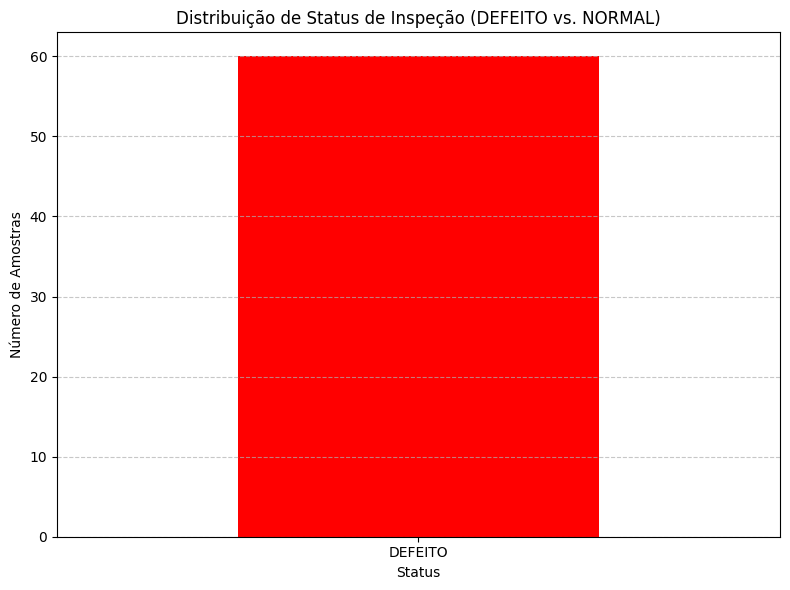

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Caminho para o diretório do modelo onde o CSV é salvo
MODEL_DIR = "/content/drive/MyDrive/modelo"
CSV_SAIDA = os.path.join(MODEL_DIR, "log_inspecao_solda.csv")

if os.path.exists(CSV_SAIDA):
    print(f"Lendo os resultados da inspeção de: {CSV_SAIDA}")
    df_resultados = pd.read_csv(CSV_SAIDA)

    # Contar o número de amostras com status 'DEFEITO' e 'NORMAL'
    status_counts = df_resultados['status'].value_counts()

    print("\nContagem de Status de Inspeção:")
    print(status_counts)

    # Gerar o gráfico de barras
    plt.figure(figsize=(8, 6))
    status_counts.plot(kind='bar', color=['red', 'green'])
    plt.title('Distribuição de Status de Inspeção (DEFEITO vs. NORMAL)')
    plt.xlabel('Status')
    plt.ylabel('Número de Amostras')
    plt.xticks(rotation=0) # Manter os rótulos do eixo X horizontais
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Erro: O arquivo de resultados da inspeção não foi encontrado em: {CSV_SAIDA}")
    print("Certifique-se de que a função main() foi executada e gerou o CSV.")